In [ ]:
# Notebook setup
import sys
from pathlib import Path
base = Path.cwd()
source = next((p for p in (base, *base.parents) if (p / "code/pyproject.toml").is_file()), base / "Release-Client.zip")
if not source.exists() and "google.colab" in sys.modules:
    from google.colab import files
    print("Required file: Release-Client.zip (project code). Choose this ZIP; data files are requested next.", flush=True)
    files.upload(target_dir=str(base))
if not source.exists():
    raise FileNotFoundError("Supply Release-Client.zip, or open the extracted code/notebooks folder.")
sys.path.insert(0, str(source / "cost-aware-market-forecasting" if source.is_file() else source))
sys.modules.pop("run_zip", None)
from run_zip import prepare_reader
CODE = CODE_ROOT = prepare_reader('03_RQ1_C_BTC_CatBoost_economic_objectives.ipynb', source, ())

# 03 - RQ1_C: BTC CatBoost economic objectives

## Methodology

Fixed, F1-selected and economically selected CatBoost configurations share DZ55/65/75 and 24 market features. Fifteen seeded configurations are compared on five 2024 blocked folds. F1 selection ranks weakest-regime then overall macro-F1; economic selection ranks adequacy failures before robust and pooled economics. The fixed control uses 300 iterations, depth 6, learning rate 0.10, L2 3, balanced classes and seed 42.

Six H1-2025 monthly predictions use preceding 180-day histories to compare 33 confidence/TP/SL policies. Adequacy requires 50 trades, 15 per side and four positive months; failing rows remain diagnostic. The July fit and H1 policy stay fixed through March 2026, with M1 execution, a one-M15 hold and 10 bps round-trip costs. Q2-2026 results are reported separately in Notebook 22.

In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

CURRENT = Path.cwd()
CODE_ROOT = CURRENT if (CURRENT / "experiments").exists() else CURRENT.parent
sys.path.insert(0, str(CODE_ROOT))

from experiments.notebook02_handoff import (
    MATCHED_ROOT,
    PIPELINE_HANDOFF,
    load_pipeline_handoff,
)
from experiments.notebook02b_handoff import HANDOFF_PATH, load_notebook02b_handoff

ARTIFACT_ROOT = MATCHED_ROOT
upstream = load_pipeline_handoff(PIPELINE_HANDOFF)
downstream = load_notebook02b_handoff(HANDOFF_PATH)
HISTORY = {int(width): int(days) for width, days in upstream["training_histories_days"].items()}
ARM_NAMES = {"baseline": "Fixed baseline", "F1": "F1-tuned", "economic": "Economic-tuned"}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

In [3]:
artifact_rows = {
    "selected_candidates_2024.parquet": 9,
    "economic_candidate_winners_2024.parquet": 45,
    "selected_policies_2025h1.parquet": 9,
    "forward_summary.parquet": 9,
    "forward_quarterly.parquet": 27,
    "forward_monthly.parquet": 81,
}
artifacts = {}
for name, expected_rows in artifact_rows.items():
    frame = pd.read_parquet(ARTIFACT_ROOT / name)
    assert len(frame) == expected_rows, (name, len(frame), expected_rows)
    artifacts[name] = frame

selected_candidates = artifacts["selected_candidates_2024.parquet"]
candidate_economics = artifacts["economic_candidate_winners_2024.parquet"]
selected_policies = artifacts["selected_policies_2025h1.parquet"]
forward_summary = artifacts["forward_summary.parquet"]
forward_quarterly = artifacts["forward_quarterly.parquet"]
forward_monthly = artifacts["forward_monthly.parquet"]
manifest = json.loads((ARTIFACT_ROOT / "manifest.json").read_text(encoding="utf-8"))

assert manifest["upstream_notebook02_handoff_fingerprint"] == upstream["handoff_fingerprint"]
assert manifest["training_histories_days"] == upstream["training_histories_days"]
assert manifest["feature_columns"] == upstream["features"]["columns"]
assert manifest["sealed_lockbox"] is True
assert manifest["lockbox_start"].startswith("2026-04-01")
assert manifest["calibration"]["method"] == "monthly_walk_forward"
assert manifest["calibration"]["month_count"] == 6
assert len(manifest["calibration"]["physical_fit_ids"]) == 54
assert forward_monthly.groupby(["objective", "width_bps"]).size().eq(9).all()
assert forward_quarterly.groupby(["objective", "width_bps"]).size().eq(3).all()

## 1. Hyperparameter selection

The table reports 2024 candidate selection. Net return, Sortino, Sharpe and trades describe each candidate's best pooled screening policy; the 180-day operational history is not the blocked-CV window.

In [4]:
from IPython.display import Markdown
candidate_table = (
    selected_candidates
    .merge(
        candidate_economics[[
            "width_bps", "candidate_id", "trades", "pooled_net", "pooled_sortino", "pooled_sharpe",
        ]],
        on=["width_bps", "candidate_id"],
        how="left",
        validate="one_to_one",
    )
    .assign(
        Objective=lambda frame: frame["objective"].map(ARM_NAMES),
        **{
            "Selection data": "Full 2024 blocking CV",
            "Operational history": lambda frame: frame["width_bps"].map(HISTORY).map(lambda days: f"{days}D"),
        },
    )
    [[
        "Objective", "width_bps", "Operational history", "candidate_id", "overall_f1", "robust_f1",
        "pooled_net", "pooled_sortino", "pooled_sharpe", "trades",
    ]]
    .rename(columns={
        "width_bps": "DZ (bps)",
        "candidate_id": "Candidate",
        "overall_f1": "Overall macro-F1",
        "robust_f1": "Robust F1",
        "pooled_net": "Net return",
        "pooled_sortino": "Sortino",
        "pooled_sharpe": "Sharpe",
        "trades": "Trades",
    })
    .sort_values(["DZ (bps)", "Objective"])
    .reset_index(drop=True)
)
candidate_table[["Overall macro-F1", "Robust F1"]] = candidate_table[["Overall macro-F1", "Robust F1"]].round(4)
candidate_table[["Sortino", "Sharpe"]] = candidate_table[["Sortino", "Sharpe"]].round(3)
candidate_table["Trades"] = candidate_table["Trades"].astype(int)
candidate_table["Net return"] = candidate_table["Net return"].map(lambda value: f"{100 * value:.2f}%")
display(Markdown('Each objective selects from the same 15 configurations using 2024 evidence at each registered width.'))
display(candidate_table)

Each objective selects from the same 15 configurations using 2024 evidence at each registered width.

,Objective,DZ (bps),Operational history,Candidate,Overall macro-F1,Robust F1,Net return,Sortino,Sharpe,Trades
0,Economic-tuned,55,180D,13,0.4035,0.3353,-1.45%,-0.807,-0.509,66
1,F1-tuned,55,180D,7,0.4027,0.3455,-10.23%,-5.372,-4.044,85
2,Fixed baseline,55,180D,0,0.3767,0.3294,-13.49%,-6.415,-5.118,98
3,Economic-tuned,65,180D,13,0.3915,0.3221,-2.90%,-1.512,-0.964,74
4,F1-tuned,65,180D,10,0.3880,0.3422,-6.31%,-3.413,-2.421,64
5,Fixed baseline,65,180D,0,0.3693,0.3378,-10.59%,-6.282,-4.872,63
6,Economic-tuned,75,180D,6,0.3714,0.3303,-9.18%,-4.711,-3.258,90
7,F1-tuned,75,180D,5,0.3647,0.3427,-17.06%,-7.743,-6.137,94
8,Fixed baseline,75,180D,0,0.3451,0.3205,-16.58%,-7.859,-6.326,83


## 2. H1 policy calibration

Six monthly prediction blocks score all 33 policies, with adequacy assessed before economic ranking. These choices set execution rules, not new model parameters.

In [5]:
from IPython.display import Markdown
calibration_table = (
    selected_policies
    .assign(
        Objective=lambda frame: frame["objective"].map(ARM_NAMES),
        **{"Training history": lambda frame: frame["width_bps"].map(HISTORY).map(lambda days: f"{days}D")},
    )
    [[
        "Objective", "width_bps", "Training history", "candidate_id", "policy_id", "tau", "tp_bps", "sl_bps",
        "pooled_net", "pooled_sortino", "pooled_sharpe", "trades", "n_long", "n_short", "positive_segments",
    ]]
    .rename(columns={
        "width_bps": "DZ (bps)", "candidate_id": "Candidate",
        "policy_id": "Policy", "tau": "Confidence", "tp_bps": "TP (bps)", "sl_bps": "SL (bps)",
        "pooled_net": "Net return", "pooled_sortino": "Sortino", "pooled_sharpe": "Sharpe",
        "trades": "Trades", "n_long": "Long trades", "n_short": "Short trades",
        "positive_segments": "Positive months",
    })
    .sort_values(["DZ (bps)", "Objective"])
    .reset_index(drop=True)
)
calibration_table["Net return"] = (100 * calibration_table["Net return"]).round(2).astype(str) + "%"
calibration_table[["Sortino", "Sharpe"]] = calibration_table[["Sortino", "Sharpe"]].round(3)
display(Markdown('Six causal H1 monthly blocks score 33 policies with adequacy-first economic selection.'))
display(calibration_table)

Six causal H1 monthly blocks score 33 policies with adequacy-first economic selection.

,Objective,DZ (bps),Training history,Candidate,Policy,Confidence,TP (bps),SL (bps),Net return,Sortino,Sharpe,Trades,Long trades,Short trades,Positive months
0,Economic-tuned,55,180D,13,20,0.75,150,100,-8.16%,-3.081,-2.421,76,56,20,2
1,F1-tuned,55,180D,7,19,0.70,150,100,-9.09%,-3.627,-2.864,69,46,23,2
2,Fixed baseline,55,180D,0,20,0.75,150,100,-9.38%,-3.540,-2.730,77,46,31,1
3,Economic-tuned,65,180D,13,20,0.75,150,100,-7.85%,-2.368,-1.709,120,84,36,1
4,F1-tuned,65,180D,10,19,0.70,150,100,-24.25%,-5.487,-4.131,214,145,69,1
5,Fixed baseline,65,180D,0,19,0.70,150,100,-15.03%,-4.634,-3.658,106,61,45,2
6,Economic-tuned,75,180D,6,31,0.75,200,100,-0.66%,-0.219,-0.144,117,80,37,3
7,F1-tuned,75,180D,5,9,0.75,150,75,-2.39%,-0.762,-0.509,122,87,35,2
8,Fixed baseline,75,180D,0,30,0.70,200,100,-0.27%,-0.098,-0.067,71,41,30,2


## 3. Development-forward comparison

The July 2025 model fit and H1-selected policy stay fixed through March 2026.

In [6]:
from IPython.display import Markdown
forward_table = (
    forward_summary
    .assign(
        Objective=lambda frame: frame["objective"].map(ARM_NAMES),
        **{"Training history": lambda frame: frame["width_bps"].map(HISTORY).map(lambda days: f"{days}D")},
    )
    [[
        "Objective", "width_bps", "Training history", "candidate_id", "policy_id", "tau", "tp_bps", "sl_bps",
        "net_return", "sortino", "sharpe", "trades", "n_long", "n_short", "positive_months",
        "long_net", "short_net", "bull_sortino", "sideways_sortino", "bear_sortino", "constraint_violation",
    ]]
    .rename(columns={
        "width_bps": "DZ (bps)", "candidate_id": "Candidate",
        "policy_id": "Policy", "tau": "Confidence", "tp_bps": "TP (bps)", "sl_bps": "SL (bps)",
        "net_return": "Net return", "sortino": "Sortino", "sharpe": "Sharpe", "trades": "Trades",
        "n_long": "Long trades", "n_short": "Short trades", "positive_months": "Positive months",
        "long_net": "Long net", "short_net": "Short net", "bull_sortino": "Bull Sortino",
        "sideways_sortino": "Sideways Sortino", "bear_sortino": "Bear Sortino",
        "constraint_violation": "Diagnostic shortfall",
    })
    .sort_values(["DZ (bps)", "Objective"])
    .reset_index(drop=True)
)
for column in ("Net return", "Long net", "Short net"):
    forward_table[column] = (100 * forward_table[column]).round(2).astype(str) + "%"
forward_table[["Sortino", "Sharpe", "Bull Sortino", "Sideways Sortino", "Bear Sortino"]] = forward_table[["Sortino", "Sharpe", "Bull Sortino", "Sideways Sortino", "Bear Sortino"]].round(3)
display(Markdown('The July fit and H1 policy are replayed unchanged through March 2026 after 10 bps per round trip.'))
display(forward_table)

The July fit and H1 policy are replayed unchanged through March 2026 after 10 bps per round trip.

,Objective,DZ (bps),Training history,Candidate,Policy,Confidence,TP (bps),SL (bps),Net return,Sortino,Sharpe,Trades,Long trades,Short trades,Positive months,Long net,Short net,Bull Sortino,Sideways Sortino,Bear Sortino,Diagnostic shortfall
0,Economic-tuned,55,180D,13,20,0.75,150,100,-6.51%,-1.744,-1.262,86,53,33,5,-6.91%,0.4%,-0.595,-4.093,-1.595,1.0
1,F1-tuned,55,180D,7,19,0.70,150,100,-6.4%,-2.058,-1.570,67,34,33,5,-4.07%,-2.33%,-1.582,-3.030,-2.329,1.0
2,Fixed baseline,55,180D,0,20,0.75,150,100,-21.5%,-5.330,-4.623,92,54,38,1,-12.25%,-9.25%,-1.335,-5.080,-7.270,5.0
3,Economic-tuned,65,180D,13,20,0.75,150,100,-25.04%,-4.671,-3.743,166,104,62,3,-19.59%,-5.45%,-3.646,-6.400,-4.882,3.0
4,F1-tuned,65,180D,10,19,0.70,150,100,-41.62%,-6.273,-5.004,310,181,129,2,-28.22%,-13.4%,-5.139,-4.789,-8.156,4.0
5,Fixed baseline,65,180D,0,19,0.70,150,100,-24.57%,-4.736,-3.859,151,84,67,3,-14.62%,-9.95%,-5.110,-6.972,-4.455,3.0
6,Economic-tuned,75,180D,6,31,0.75,200,100,-27.72%,-5.421,-4.379,162,121,41,2,-17.1%,-10.62%,-5.248,-4.674,-6.438,4.0
7,F1-tuned,75,180D,5,9,0.75,150,75,-19.61%,-4.554,-3.628,120,88,32,1,-11.4%,-8.21%,-2.202,-4.487,-6.011,5.0
8,Fixed baseline,75,180D,0,30,0.70,200,100,-8.01%,-2.098,-1.474,92,58,34,4,-2.24%,-5.77%,-2.265,-2.125,-2.562,2.0


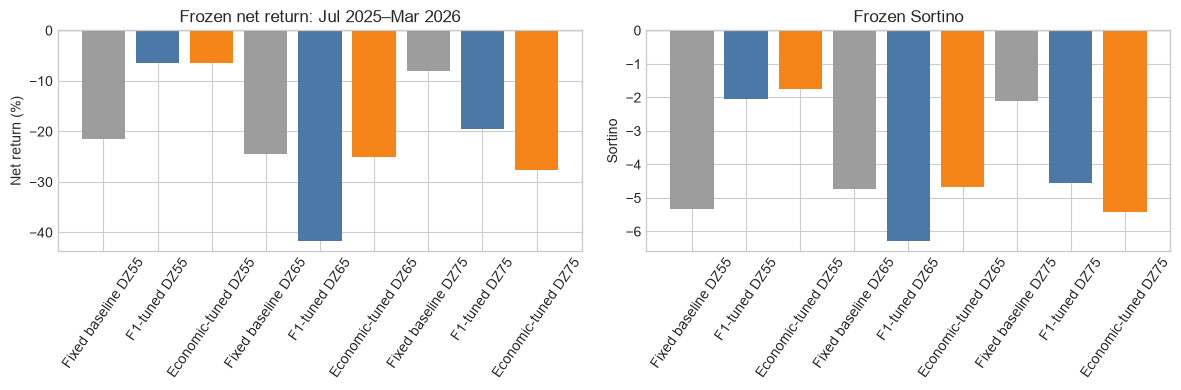

In [7]:
plot_frame = forward_summary.copy()
plot_frame["Series"] = plot_frame["objective"].map(ARM_NAMES) + " DZ" + plot_frame["width_bps"].astype(str)
colors = {"baseline": "#9d9d9d", "F1": "#4c78a8", "economic": "#f58518"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(plot_frame["Series"], 100 * plot_frame["net_return"], color=[colors[value] for value in plot_frame["objective"]])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Frozen net return: Jul 2025–Mar 2026")
axes[0].set_ylabel("Net return (%)")
axes[0].tick_params(axis="x", rotation=55)
axes[1].bar(plot_frame["Series"], plot_frame["sortino"], color=[colors[value] for value in plot_frame["objective"]])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Frozen Sortino")
axes[1].set_ylabel("Sortino")
axes[1].tick_params(axis="x", rotation=55)
fig.tight_layout()
plt.show()

## 4. Differences between selection objectives

Within each DZ, the table subtracts the fixed baseline or F1-selected result from the comparator. Net-return differences are percentage-point changes, not additional strategy profits.

In [8]:
from IPython.display import Markdown
metrics = ["net_return", "sortino", "sharpe", "trades"]
pivot = forward_summary.pivot(index="width_bps", columns="objective", values=metrics)
comparisons = [
    ("F1-tuned minus baseline", "F1", "baseline"),
    ("Economic-tuned minus baseline", "economic", "baseline"),
    ("Economic-tuned minus F1-tuned", "economic", "F1"),
]
rows = []
for label, left, right in comparisons:
    for width in pivot.index:
        rows.append({
            "Comparison": label,
            "DZ (bps)": width,
            "Net-return difference": pivot.loc[width, ("net_return", left)] - pivot.loc[width, ("net_return", right)],
            "Sortino difference": pivot.loc[width, ("sortino", left)] - pivot.loc[width, ("sortino", right)],
            "Sharpe difference": pivot.loc[width, ("sharpe", left)] - pivot.loc[width, ("sharpe", right)],
            "Trade-count difference": pivot.loc[width, ("trades", left)] - pivot.loc[width, ("trades", right)],
        })
difference_table = pd.DataFrame(rows)
difference_table["Net-return difference"] = (100 * difference_table["Net-return difference"]).round(2).astype(str) + "%"
difference_table[["Sortino difference", "Sharpe difference"]] = difference_table[["Sortino difference", "Sharpe difference"]].round(3)
display(Markdown('Within each width, forward results are differenced between fixed, F1-selected and economic-selected candidates.'))
display(difference_table)

Within each width, forward results are differenced between fixed, F1-selected and economic-selected candidates.

,Comparison,DZ (bps),Net-return difference,Sortino difference,Sharpe difference,Trade-count difference
0,F1-tuned minus baseline,55,15.1%,3.272,3.053,-25.0
1,F1-tuned minus baseline,65,-17.05%,-1.537,-1.145,159.0
2,F1-tuned minus baseline,75,-11.59%,-2.455,-2.154,28.0
3,Economic-tuned minus baseline,55,14.99%,3.586,3.362,-6.0
4,Economic-tuned minus baseline,65,-0.47%,0.065,0.116,15.0
5,Economic-tuned minus baseline,75,-19.7%,-3.323,-2.905,70.0
6,Economic-tuned minus F1-tuned,55,-0.11%,0.314,0.309,19.0
7,Economic-tuned minus F1-tuned,65,16.58%,1.602,1.262,-144.0
8,Economic-tuned minus F1-tuned,75,-8.11%,-0.868,-0.751,42.0


## Execution data

Binance M15 candles and futures positioning form the 24 predictors; native M1 OHLC prices score TP/SL paths after each decision, using the registered rule when both barriers touch within one minute.

## Results

All nine variants lose after costs in the July 2025 to March 2026 comparison. F1-tuned DZ55 has the least negative net return (-6.40%, 67 trades); Economic-tuned DZ55 has the highest Sortino (-1.744, 86 trades). No H1-selected row reaches the required four positive calibration months. Forward rankings are descriptive, and the configuration/policy search carries multiple-comparison risk.

Takeaway: Economic selection changes relative performance without producing a profitable strategy in this comparison.